In [1]:
import os
import pandas as pd

# Path relatif dari final_project/notebooks ke direktori dataset yolo
dataset_path = "../data/raw/final_project.yolo"

def get_dataset_df(split_name):
    # Folder validasi menggunakan nama 'valid' di sistem direktori
    folder_name = "valid" if split_name == "val" else split_name
    images_dir = os.path.join(dataset_path, folder_name, "images")
    labels_dir = os.path.join(dataset_path, folder_name, "labels")
    
    if not os.path.exists(images_dir):
        print(f"Direktori {images_dir} tidak ditemukan!")
        return pd.DataFrame()
        
    data = []
    for img_file in sorted(os.listdir(images_dir)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            base_name, ext = os.path.splitext(img_file)
            label_file = base_name + ".txt"
            label_path = os.path.join(labels_dir, label_file)
            
            # Ekstrak class name langsung dari nama file yang sudah di-rename (format: split_class_counter)
            parts = base_name.split('_')
            class_name = parts[1] if len(parts) > 1 else "unknown"
            
            data.append({
                "image_name": img_file,
                "label_name": label_file,
                "class": class_name,
                "image_path": os.path.join(images_dir, img_file),
                "label_path": label_path
            })
            
    return pd.DataFrame(data)

# Mengisi variabel sesuai yang ada di cell notebook Anda
train = get_dataset_df("train")
val = get_dataset_df("val")
test = get_dataset_df("test")

# Menampilkan jumlah sampel di setiap split
print(f"Train samples: {len(train)}")
print(f"Val samples:   {len(val)}")
print(f"Test samples:  {len(test)}")


Train samples: 1747
Val samples:   401
Test samples:  404


In [2]:
# 1. Tambahkan kolom penanda split
train['split'] = 'train'
val['split'] = 'val'
test['split'] = 'test'

# 2. Gabungkan ketiga dataframe
df_all = pd.concat([train, val, test])

# 3. Gunakan crosstab untuk membuat tabel kontingensi 
summary_df = pd.crosstab(index=df_all['class'], columns=df_all['split'])
summary_df


split,test,train,val
class,,,
awake,213,874,208
drowsy,191,873,193


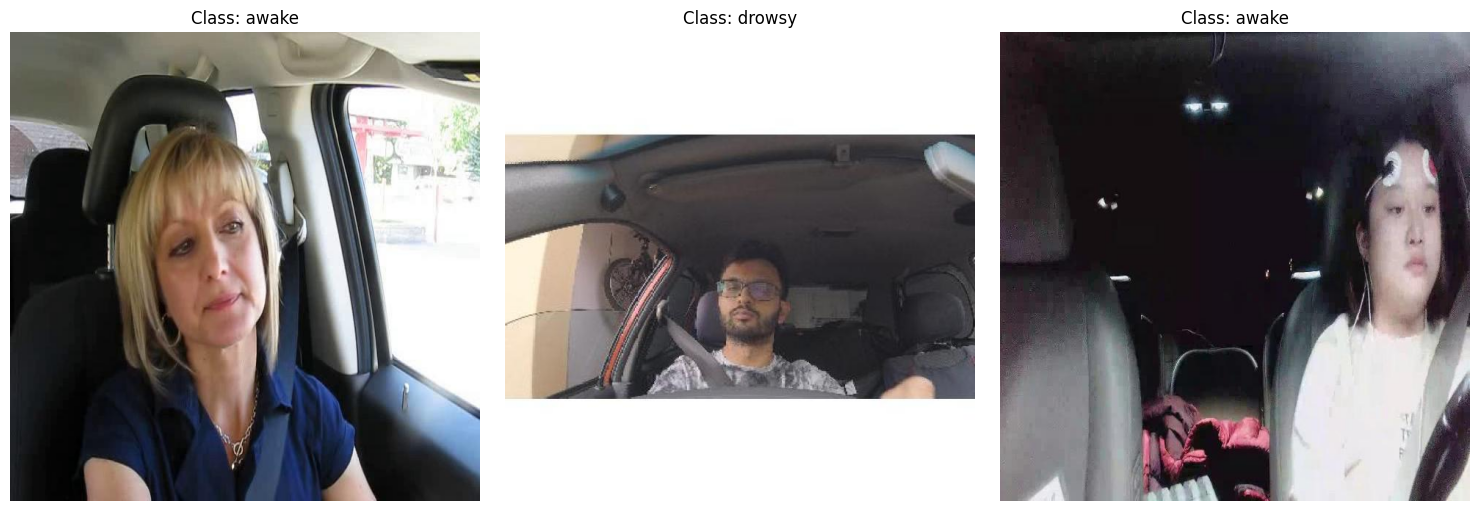

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(df, num_samples=3):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    # Ambil sampel acak dari dataframe
    samples = df.sample(min(num_samples, len(df)))
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['image_path'])
        ax = axes[idx] if num_samples > 1 else axes
        ax.imshow(img)
        ax.set_title(f"Class: {row['class']}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Menampilkan 3 sampel dari data training
show_samples(train, num_samples=3)


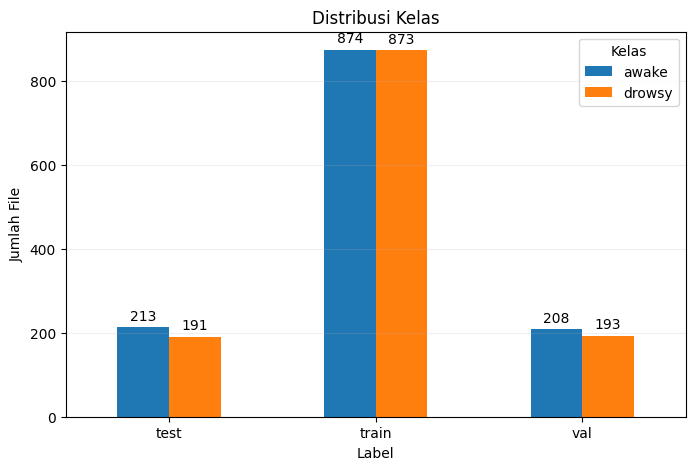

In [4]:
ax = summary_df.T.plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])

# Menampilkan jumlah di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title('Distribusi Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah File')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)
plt.legend(title='Kelas')
plt.show()

## Sample Gambar Beserta Bounding Box
Menampilkan 6 gambar acak dari dataset training lengkap dengan bounding box dan label kelasnya.

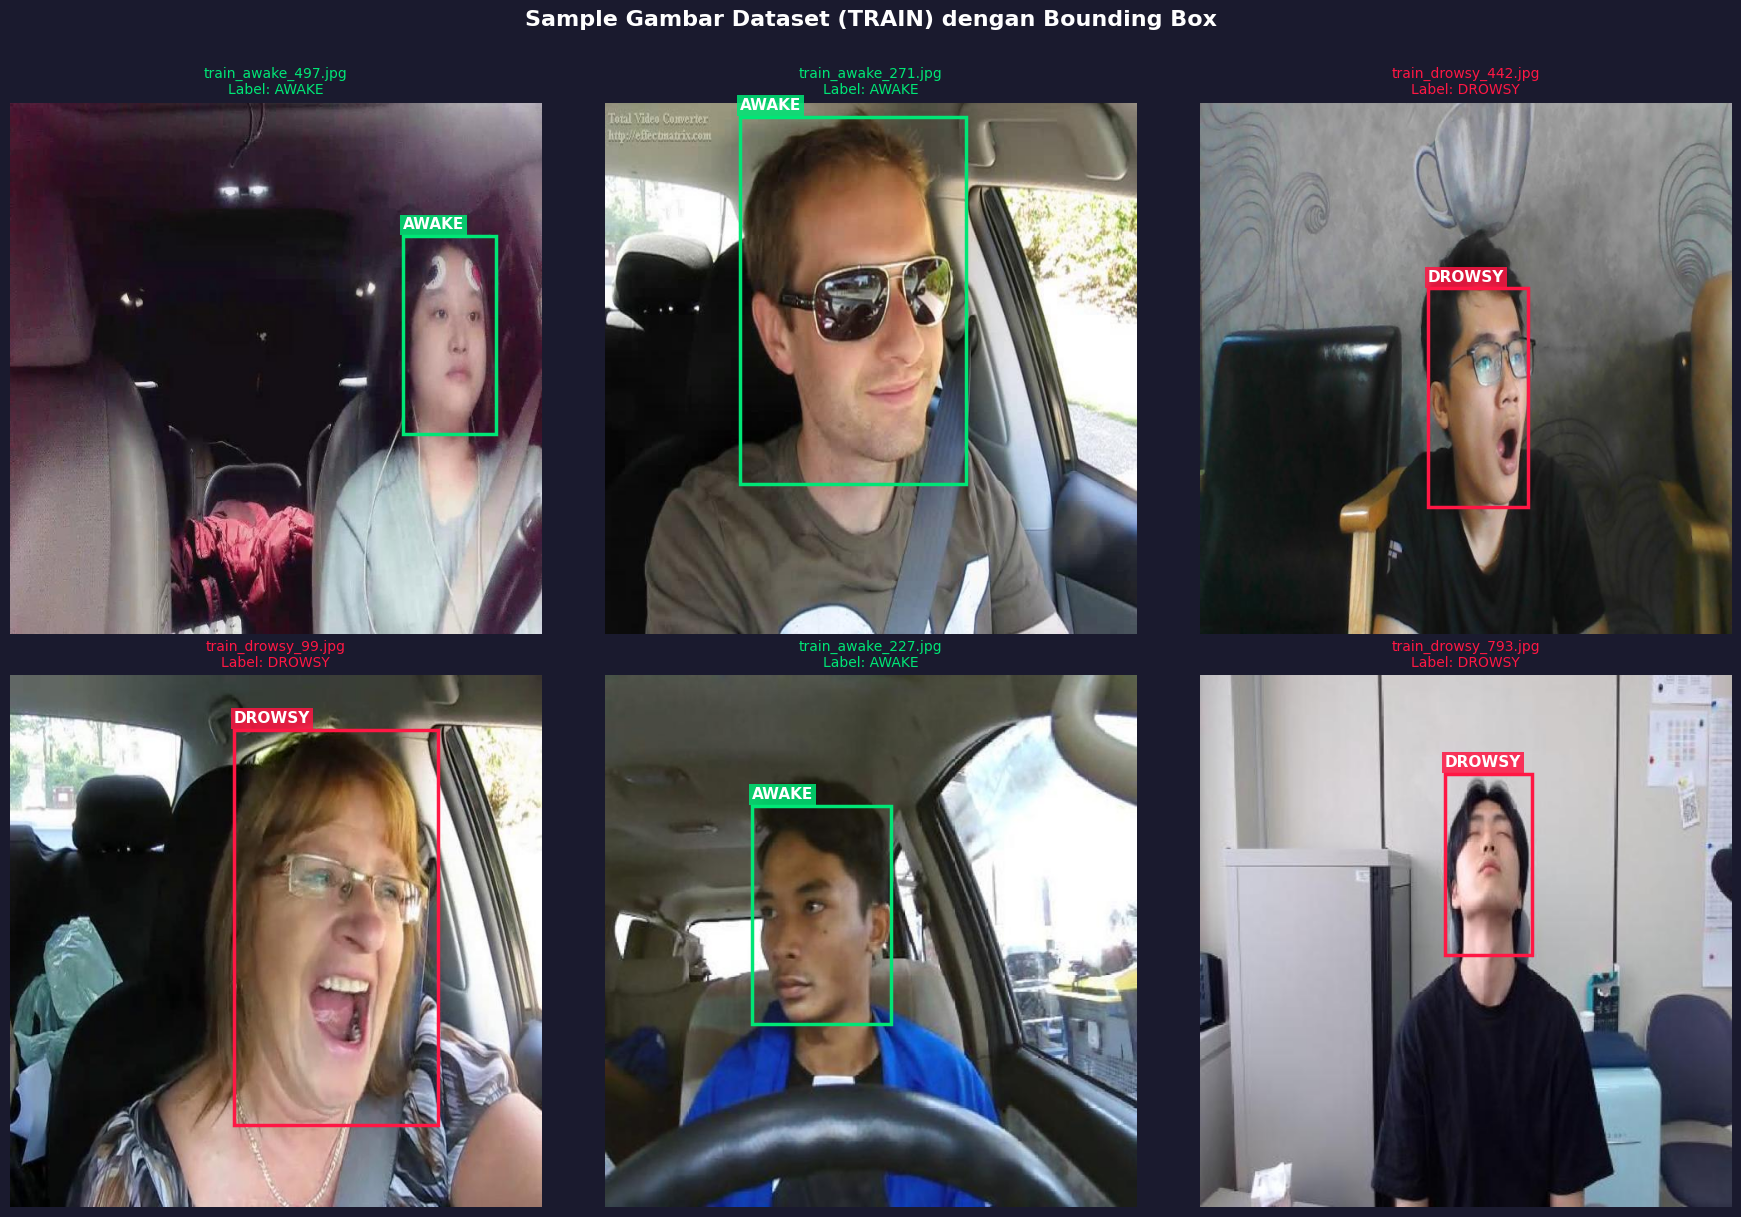

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Konfigurasi
DATASET_PATH = "../data/raw/final_project.yolo"
SPLIT = "train"  # Bisa diganti: 'valid' atau 'test'
NUM_SAMPLES = 6
CLASS_NAMES = {0: 'awake', 1: 'drowsy'}
CLASS_COLORS = {'awake': '#00E676', 'drowsy': '#FF1744'}  # Hijau=awake, Merah=drowsy

def parse_yolo_label(label_path, img_w, img_h):
    """Parse file label YOLO dan konversi ke koordinat piksel."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            # Konversi dari format YOLO (normalized center x,y,w,h) ke corner coords
            x1 = (cx - bw / 2) * img_w
            y1 = (cy - bh / 2) * img_h
            box_w = bw * img_w
            box_h = bh * img_h
            boxes.append({'class_id': class_id, 'x1': x1, 'y1': y1, 'w': box_w, 'h': box_h})
    return boxes

def show_samples_with_bbox(split=SPLIT, num_samples=NUM_SAMPLES):
    images_dir = os.path.join(DATASET_PATH, split, 'images')
    labels_dir = os.path.join(DATASET_PATH, split, 'labels')

    all_images = [f for f in os.listdir(images_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(all_images) == 0:
        print(f'Tidak ada gambar di folder {images_dir}')
        return

    # Filter gambar berdasarkan kelas pada nama file
    awake_images = []
    drowsy_images = []
    for f in all_images:
        parts = os.path.splitext(f)[0].split('_')
        if len(parts) > 1:
            lbl = parts[1].lower()
            if lbl == 'awake':
                awake_images.append(f)
            elif lbl == 'drowsy':
                drowsy_images.append(f)

    # Ambil sampel secara seimbang (masing-masing setengah dari num_samples)
    half_samples = num_samples // 2
    samples_awake = random.sample(awake_images, min(half_samples, len(awake_images)))
    samples_drowsy = random.sample(drowsy_images, min(num_samples - len(samples_awake), len(drowsy_images)))
    
    samples = samples_awake + samples_drowsy
    random.shuffle(samples)

    cols = 3
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 6))
    fig.patch.set_facecolor('#1a1a2e')
    axes = axes.flatten()

    for idx, img_file in enumerate(samples):
        ax = axes[idx]
        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + '.txt')

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        ax.imshow(img)
        ax.set_facecolor('#1a1a2e')

        boxes = parse_yolo_label(label_path, img_w, img_h)
        for box in boxes:
            class_name = CLASS_NAMES.get(box['class_id'], 'unknown')
            color = CLASS_COLORS.get(class_name, 'white')
            rect = patches.Rectangle(
                (box['x1'], box['y1']), box['w'], box['h'],
                linewidth=2.5, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                box['x1'], box['y1'] - 8,
                class_name.upper(),
                color='white', fontsize=11, fontweight='bold',
                bbox=dict(facecolor=color, edgecolor='none', alpha=0.85, pad=2)
            )

        # Ekstrak label dari nama file
        parts = os.path.splitext(img_file)[0].split('_')
        file_label = parts[1].upper() if len(parts) > 1 else 'UNKNOWN'
        title_color = CLASS_COLORS.get(parts[1], 'white') if len(parts) > 1 else 'white'
        ax.set_title(f'{img_file}\nLabel: {file_label}', color=title_color, fontsize=10, pad=6)
        ax.axis('off')

    # Sembunyikan axes yang tidak terpakai
    for i in range(len(samples), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(
        f'Sample Gambar Dataset ({split.upper()}) dengan Bounding Box',
        fontsize=16, fontweight='bold', color='white', y=1.01
    )
    plt.tight_layout()
    plt.show()

show_samples_with_bbox()

## Perbandingan Parameter Eksperimen
Menampilkan tabel perbandingan parameter training yang digunakan untuk setiap versi model (baseline, v2, dan v3) berdasarkan file laporan pada direktori `reports`.

In [6]:
import os
import re
import pandas as pd

# Path ke direktori reports relatif terhadap notebook
reports_dir = "../reports"
report_files = [f for f in os.listdir(reports_dir) if f.endswith('.txt')]

data = []

for filename in sorted(report_files):
    filepath = os.path.join(reports_dir, filename)
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Ekstrak nama model dan eksperimen
    model_match = re.search(r"Model Weight\s+:\s+(\S+)", content)
    exp_match = re.search(r"Experiment Name\s+:\s+(\S+)", content)
    
    model = model_match.group(1) if model_match else "unknown"
    exp = exp_match.group(1) if exp_match else "unknown"
    
    # Ekstrak blok parameter training
    param_block_match = re.search(r"===== Training Parameters =====\n(.*?)\n=====", content, re.DOTALL)
    if not param_block_match:
        param_block_match = re.search(r"===== Training Parameters =====\n(.*)", content, re.DOTALL)
        
    params = {}
    if param_block_match:
        block = param_block_match.group(1)
        for line in block.split('\n'):
            line = line.strip()
            if not line or line.startswith('====='):
                continue
            if ':' in line:
                key, val = line.split(':', 1)
                params[key.strip()] = val.strip()
                
    params['Model'] = model
    params['Experiment'] = exp
    data.append(params)

# Buat DataFrame perbandingan
df_compare = pd.DataFrame(data)

# Rapikan susunan kolom
left_cols = ['Model', 'Experiment']
remaining_cols = [c for c in df_compare.columns if c not in left_cols]
df_compare = df_compare[left_cols + remaining_cols]

# Isi nilai kosong dengan '-' agar rapi
df_compare = df_compare.fillna('-')

# Tampilkan DataFrame
df_compare

,Model,Experiment,Epochs,Batch Size,Workers,Seed,Device,AMP,Ultralytics Ver,PyTorch Ver,Patience,Optimizer,lr0,lrf,cos_lr,degrees,shear,perspective,mosaic,mixup
0,yolo11s.pt,baseline,100,16,4,42,0 (Tesla T4),True,8.4.78,2.10.0+cu128,-,-,-,-,-,-,-,-,-,-
1,yolo11s.pt,v2,300,16,4,42,0 (Tesla T4),True,8.4.80,2.10.0+cu128,50,-,-,-,-,-,-,-,-,-
2,yolo11s.pt,v3,300,16,4,42,0 (Tesla T4),True,8.4.80,2.10.0+cu128,50,AdamW,0.0008,0.01,True,5.0,2.0,0.0005,0.5,0.05
3,yolo26s.pt,baseline,100,16,4,42,0 (Tesla T4),True,8.4.80,2.10.0+cu128,-,-,-,-,-,-,-,-,-,-
4,yolo26s.pt,v2,300,16,4,42,0 (Tesla T4),True,8.4.80,2.10.0+cu128,50,-,-,-,-,-,-,-,-,-
5,yolo26s.pt,v3,300,16,4,42,0 (Tesla T4),True,8.4.80,2.10.0+cu128,50,AdamW,0.0008,0.01,True,5.0,2.0,0.0005,0.5,0.05
